In [9]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import openpyxl

from sklearn.preprocessing import LabelEncoder,OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

In [2]:
df = pd.read_csv("dataset/customer_shopping_data.csv")
df["revenue"] = df["quantity"] * df["price"]
df["invoice_date"] = pd.to_datetime(df["invoice_date"],format='mixed')

In [3]:
df.head(3)

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,revenue
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-05-08,Kanyon,7502.00
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,5401.53
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-09-11,Metrocity,300.08


In [18]:
df["category"].value_counts()

category
Clothing           34487
Cosmetics          15097
Food & Beverage    14776
Toys               10087
Shoes              10034
Souvenir            4999
Technology          4996
Books               4981
Name: count, dtype: int64

<Axes: >

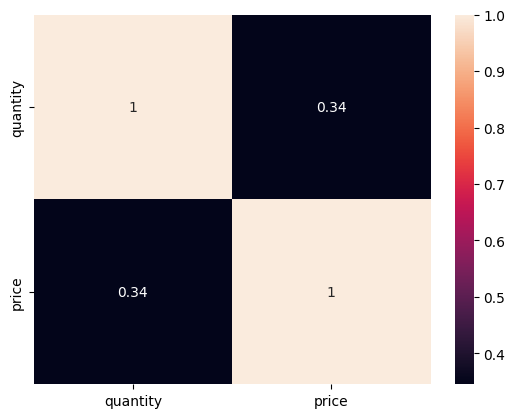

In [20]:
corr_table = df[["quantity","price"]].corr()
sns.heatmap(data=corr_table,annot=True)

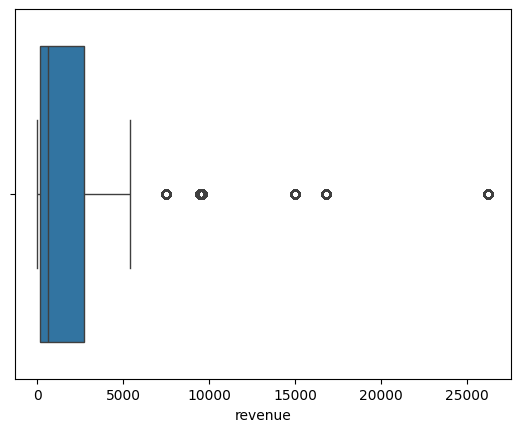

In [12]:
sns.boxplot(data=df,x="revenue")
plt.show()

In [14]:
df.loc[df["revenue"] > 6000].shape

(13986, 11)

In [24]:
le_gender = LabelEncoder()
df["label_gender"] = le_gender.fit_transform(df["gender"])

le_cat = LabelEncoder()
df["label_category"] = le_cat.fit_transform(df["category"])

print(dict(enumerate(le_gender.classes_)))

print(dict(enumerate(le_cat.classes_)))

{0: 'Female', 1: 'Male'}
{0: 'Books', 1: 'Clothing', 2: 'Cosmetics', 3: 'Food & Beverage', 4: 'Shoes', 5: 'Souvenir', 6: 'Technology', 7: 'Toys'}


In [25]:
df

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall,revenue,label_gender,label_category
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,2022-05-08,Kanyon,7502.00,0,1
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,2021-12-12,Forum Istanbul,5401.53,1,4
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,2021-09-11,Metrocity,300.08,1,1
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,2021-05-16,Metropol AVM,15004.25,0,4
4,I337046,C189076,Female,53,Books,4,60.60,Cash,2021-10-24,Kanyon,242.40,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
99452,I219422,C441542,Female,45,Souvenir,5,58.65,Credit Card,2022-09-21,Kanyon,293.25,0,5
99453,I325143,C569580,Male,27,Food & Beverage,2,10.46,Cash,2021-09-22,Forum Istanbul,20.92,1,3
99454,I824010,C103292,Male,63,Food & Beverage,2,10.46,Debit Card,2021-03-28,Metrocity,20.92,1,3
99455,I702964,C800631,Male,56,Technology,4,4200.00,Cash,2021-03-16,Istinye Park,16800.00,1,6
